<a href="https://www.kaggle.com/code/avikdas567/feature-engineered-gbdt-smartphone-addiction-auc?scriptVersionId=339492097" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predicting Smartphone Addiction: Feature-Engineered GBDT Pipeline
## Kaggle Playground Series - Season 6 Episode 8

---

## 1. Problem Formulation & Optimization Metric
This notebook models individual smartphone addiction propensity as a supervised binary classification task over $N_{\text{train}} = 691,369$ training instances and $N_{\text{test}} = 296,302$ test instances. Given a feature vector $\mathbf{x}_i \in \mathbb{R}^p$ representing user demographics, daily screen time breakdown, device interaction counts, and self-reported psychological metrics, the goal is to predict class probabilities $\hat{y}_i = P(y_i = 1 \mid \mathbf{x}_i)$ for the binary addiction target variable $y_i \in \{0, 1\}$.

Model evaluation is governed by the Area Under the Receiver Operating Characteristic Curve (ROC-AUC), formally defined as:

$$\text{ROC-AUC} = \int_{0}^{1} \text{TPR}(\text{FPR}^{-1}(t)) \, dt = P(\hat{y}_i > \hat{y}_j \mid y_i = 1, y_j = 0)$$

where $\text{TPR}$ is the True Positive Rate and $\text{FPR}$ is the False Positive Rate across all discrimination thresholds. Because ROC-AUC measures rank-order separation between positive and negative classes, preserving monotonic probability scaling is critical during model blending.

---

## 2. Dataset Architecture & Feature Topology
The input schema consists of 12 predictor variables containing mixed numerical and categorical modalities with non-random missingness patterns ($4\%$ to $19\%$ missing values per feature):

*   **Continuous Predictors**: `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours`, `sleep_hours`, `weekend_screen_time`, `notifications_per_day`, `app_opens_per_day`, `age`.
*   **Categorical Predictors**: `gender` (Male, Female, Other), `stress_level` (Low, Medium, High), `academic_work_impact` (Yes, No).

---

## 3. Behavioral Feature Derivation
Raw usage durations are transformed into non-linear interaction ratios and time-budget allocation differentials to capture non-linear behavioral signatures:

*   **Total Leisure Hours**: $H_{\text{leisure}} = H_{\text{social}} + H_{\text{gaming}}$
*   **Leisure Screen Share**: $R_{\text{leisure}} = \frac{H_{\text{leisure}}}{H_{\text{daily}} + \epsilon}$
*   **Productive Screen Share**: $R_{\text{work}} = \frac{H_{\text{work}}}{H_{\text{daily}} + \epsilon}$
*   **Weekend Usage Differential**: $\Delta_{\text{weekend}} = H_{\text{weekend}} - H_{\text{daily}}$
*   **Session Duration Estimate**: $M_{\text{session}} = \frac{H_{\text{daily}} \times 60}{N_{\text{app\_opens}} + \epsilon}$
*   **Awake Hours Screen Percentage**: $P_{\text{awake}} = \frac{H_{\text{daily}}}{24.0 - H_{\text{sleep}} + \epsilon}$
*   **Notification Density**: $D_{\text{notif}} = \frac{N_{\text{notif}}}{H_{\text{daily}} + \epsilon}$
*   **Missingness Count Metadata**: Row-wise null indicator sum $C_{\text{null}} = \sum_{j=1}^{p} \mathbb{I}(x_{ij} \text{ is NaN})$.

---

## 4. Cross-Validation Protocol
To prevent data leakage during categorical transformations, evaluation follows a Stratified 5-Fold Cross-Validation structure ($K = 5$). For each fold $k \in \{1, \dots, 5\}$:

1. Categorical features are ordinally encoded based on parameters learned exclusively from the training fold.
2. Models are trained on $80\%$ of the data and generate out-of-fold probability vectors $\mathbf{\hat{y}}_{\text{oof}}^{(k)}$ on the remaining $20\%$.
3. Test set probability predictions $\mathbf{\hat{y}}_{\text{test}}^{(k)}$ are recorded and averaged across all $K$ folds.

---

## 5. Multi-Model Ensembling & SLSQP Blending
The pipeline integrates structural diversity across four distinct Gradient Boosted Decision Tree (GBDT) algorithms:

1. **LightGBM**: Leaf-wise tree growth (`num_leaves=63`) optimizing histogram-binned split points with native missing value processing.
2. **XGBoost**: Depth-wise level growth (`max_depth=6`) utilizing GPU/CPU histogram tree methods.
3. **CatBoost**: Symmetric oblivious trees (`depth=6`) with target-based categorical processing.
4. **HistGradientBoosting**: Scikit-Learn implementation utilizing integer-binned feature splits.

Out-of-fold probability predictions $\mathbf{OOF} \in \mathbb{R}^{N_{\text{train}} \times M}$ are ensembled using Sequential Least Squares Programming (SLSQP) to determine the optimal blending weight vector $\mathbf{w}^* \in \mathbb{R}^M$:

$$\max_{\mathbf{w}} \text{ROC-AUC}\left(\mathbf{y}, \mathbf{OOF} \cdot \mathbf{w}\right) \quad \text{subject to} \quad \sum_{m=1}^{M} w_m = 1, \quad w_m \ge 0$$

# Environment Setup & Reproducibility Protocol

To ensure complete determinism and reproducibility across execution runs, all random seeds across `NumPy`, `Python`, `PyTorch`, and Gradient Boosting frameworks are fixed to a central seed value ($S = 42$).


In [1]:
import os
import sys
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

# Try importing optional libraries gracefully
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import catboost as cb
    HAS_CB = True
except ImportError:
    HAS_CB = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)
print(f"Environment configured with SEED={SEED}.")
print(f"Library Support: LightGBM={HAS_LGB}, XGBoost={HAS_XGB}, CatBoost={HAS_CB}")


Environment configured with SEED=42.
Library Support: LightGBM=True, XGBoost=True, CatBoost=True


# 1. Data Ingestion and Schema Analysis

We load the datasets directly from the Kaggle input environment paths:
* Train Path: `/kaggle/input/competitions/playground-series-s6e8/train.csv`
* Test Path: `/kaggle/input/competitions/playground-series-s6e8/test.csv`
* Sample Submission: `/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv`


In [2]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e8/train.csv'
TEST_PATH = '/kaggle/input/competitions/playground-series-s6e8/test.csv'
SUB_PATH = '/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv'

# Fallback paths for local testing if needed
if not os.path.exists(TRAIN_PATH):
    TRAIN_PATH = 'train.csv'
    TEST_PATH = 'test.csv'
    SUB_PATH = 'sample_submission.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print(f"Training Set Dimensions: {train_df.shape}")
print(f"Testing Set Dimensions:  {test_df.shape}")
print(f"Submission Dimensions:   {sample_sub.shape}")

display(train_df.head(10))


Training Set Dimensions: (691369, 14)
Testing Set Dimensions:  (296302, 13)
Submission Dimensions:   (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


# 2. Advanced Exploratory Data Analysis & Scientific Profiling

In this section, we analyze feature distributions, target incidence rates, missing value characteristics, and feature correlation structures.


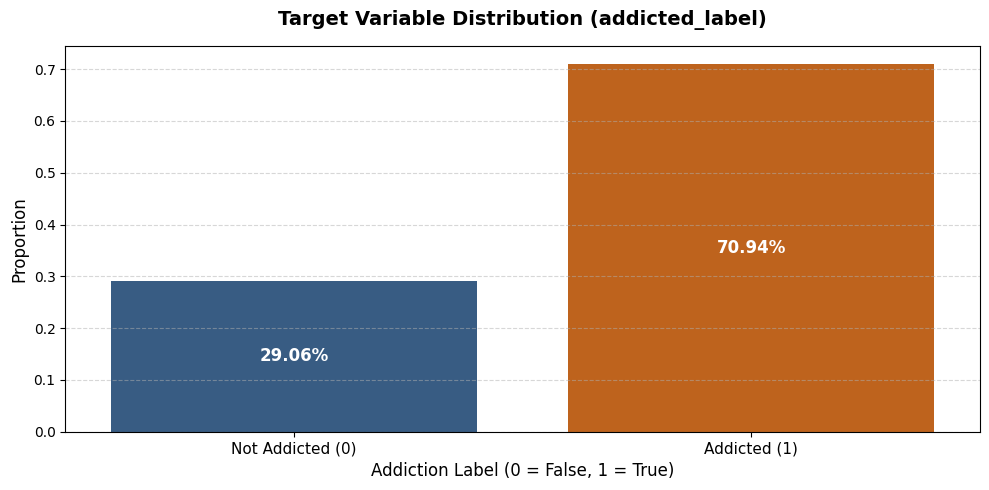

In [3]:
# Target Variable Distribution
target_counts = train_df['addicted_label'].value_counts(normalize=True)

plt.figure(figsize=(10, 5))
palette = ['#2b5c8f', '#d95f02']
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=palette)
plt.title('Target Variable Distribution (addicted_label)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Addiction Label (0 = False, 1 = True)', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks([0, 1], ['Not Addicted (0)', 'Addicted (1)'], fontsize=11)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

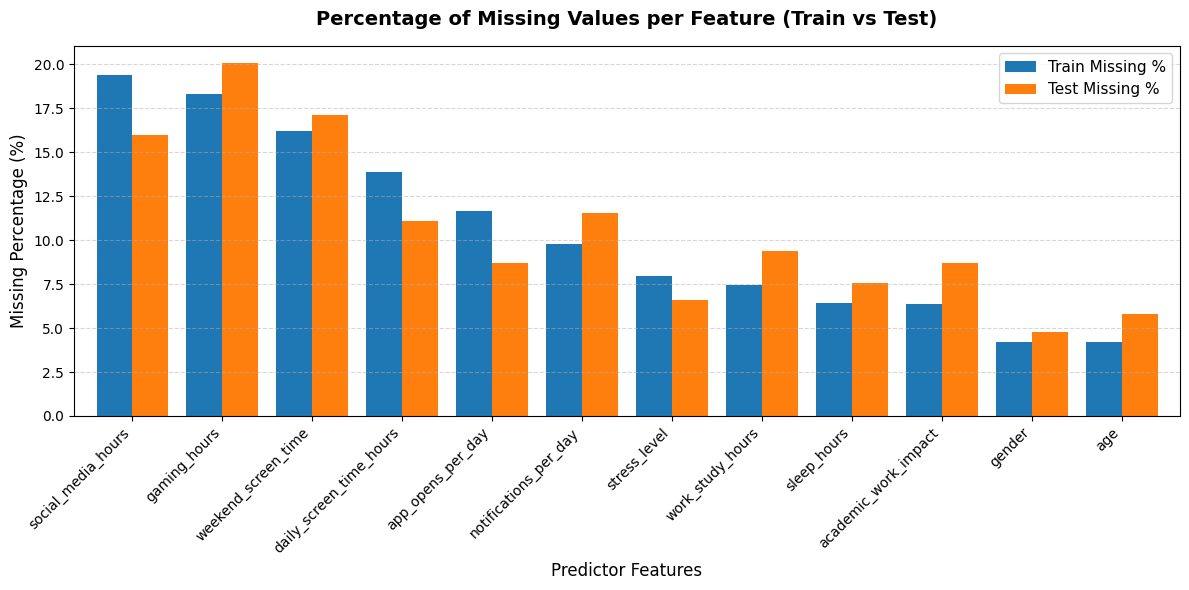

In [4]:
# Missing Value Analysis per Feature Across Datasets
train_missing = train_df.drop(columns=['id', 'addicted_label']).isnull().mean() * 100
test_missing = test_df.drop(columns=['id']).isnull().mean() * 100

missing_df = pd.DataFrame({'Train Missing %': train_missing, 'Test Missing %': test_missing}).sort_values(by='Train Missing %', ascending=False)

plt.figure(figsize=(12, 6))
missing_df.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'], width=0.8)
plt.title('Percentage of Missing Values per Feature (Train vs Test)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predictor Features', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

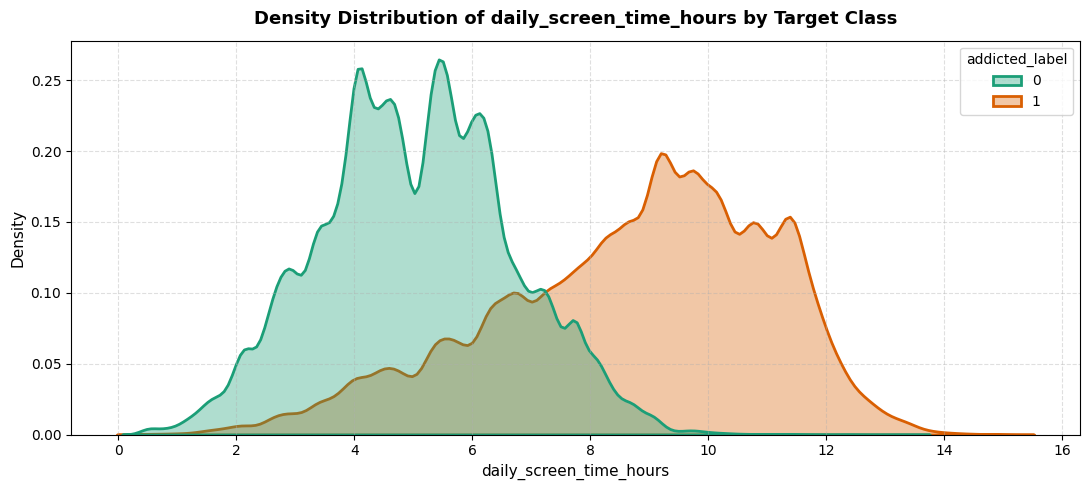

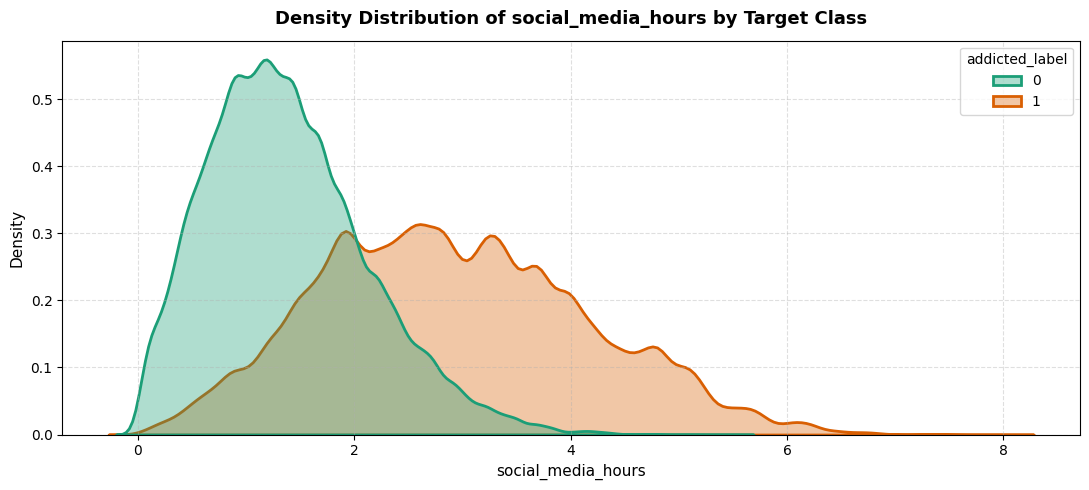

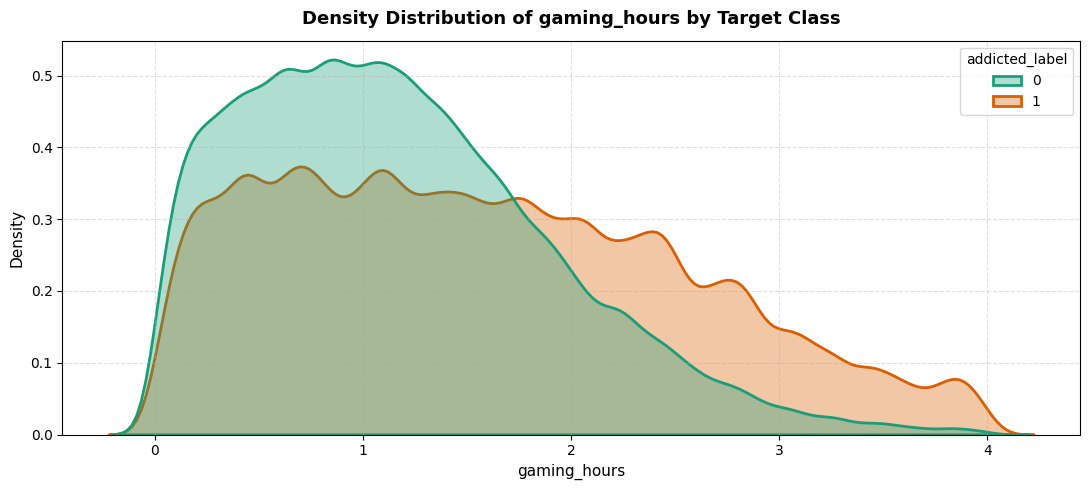

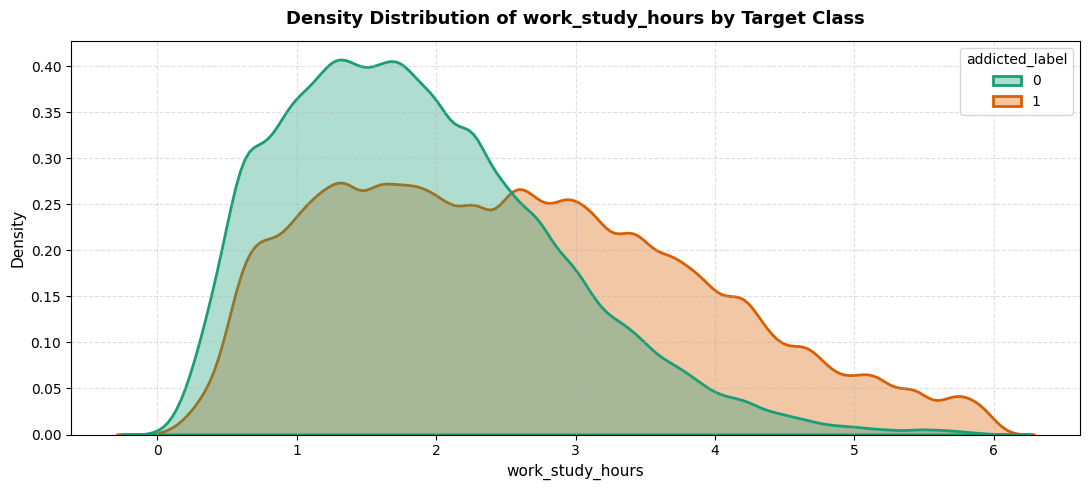

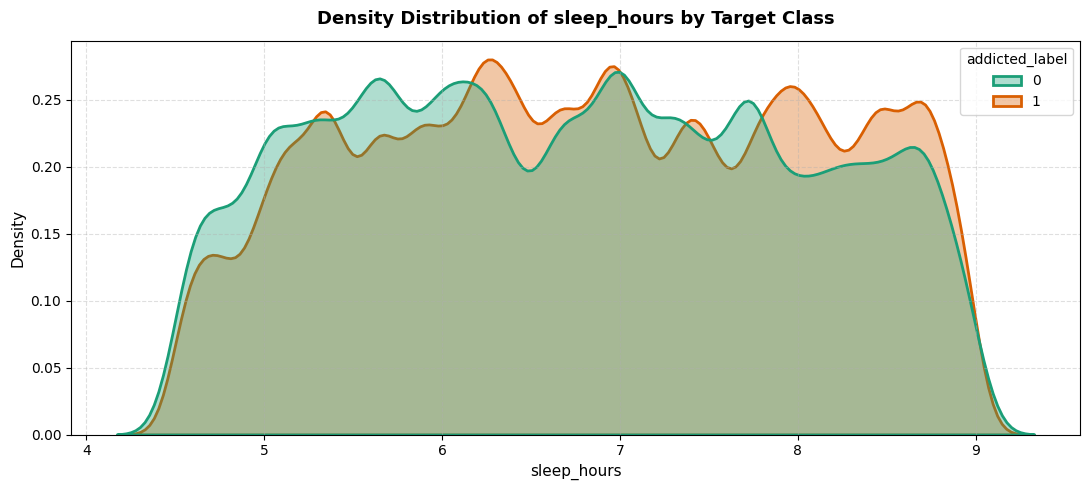

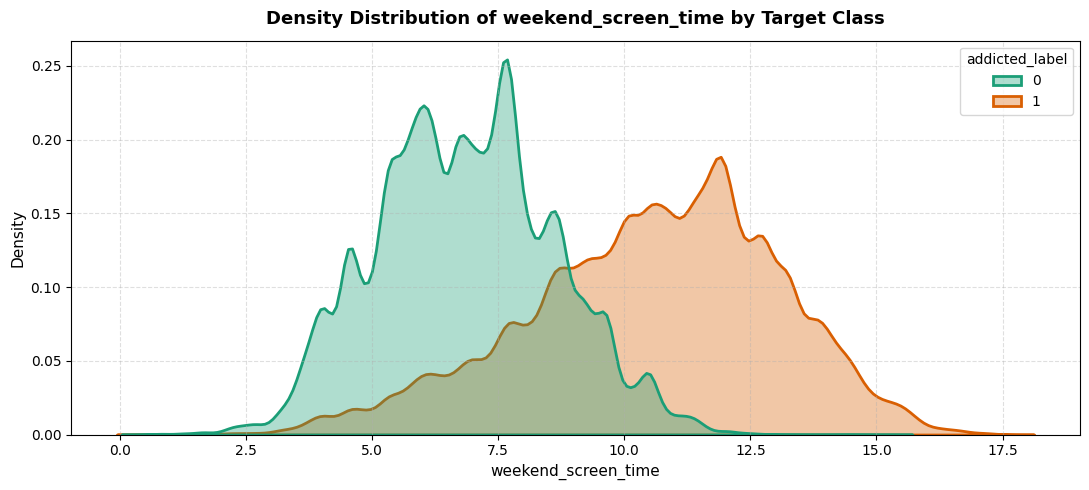

In [5]:
# Key Continuous Features Distribution by Target Status
num_features = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'weekend_screen_time']

for feat in num_features:
    plt.figure(figsize=(11, 5))
    sns.kdeplot(data=train_df, x=feat, hue='addicted_label', common_norm=False, palette=['#1b9e77', '#d95f02'], fill=True, alpha=0.35, linewidth=2)
    plt.title(f'Density Distribution of {feat} by Target Class', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel(feat, fontsize=11)
    plt.ylabel('Density', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


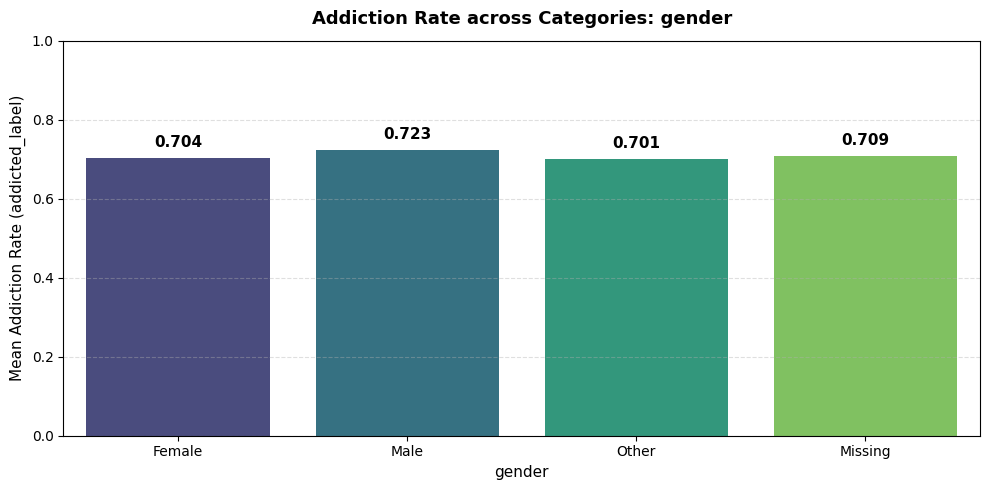

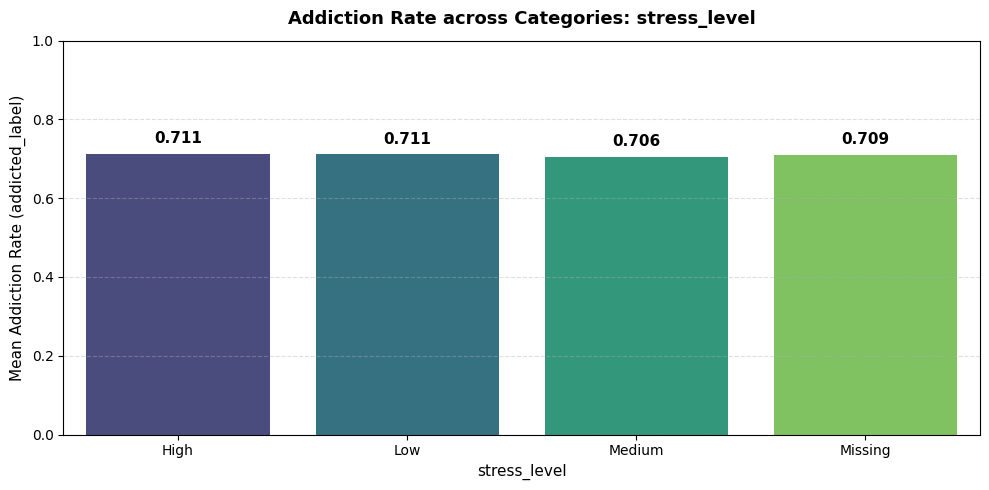

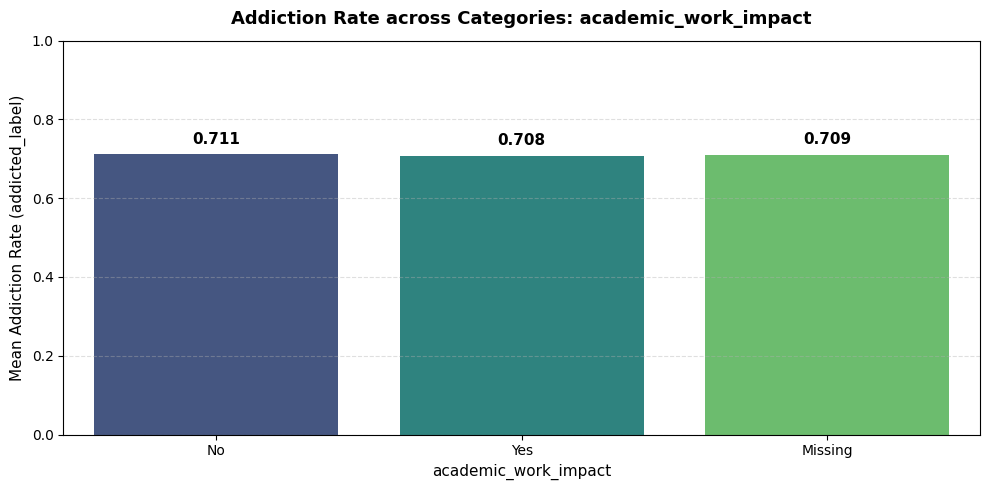

In [6]:
# Categorical Features vs Target Addiction Rate
cat_cols = ['gender', 'stress_level', 'academic_work_impact']

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    cat_rate = train_df.groupby(col, dropna=False)['addicted_label'].mean().reset_index()
    cat_rate[col] = cat_rate[col].fillna('Missing').astype(str)
    ax = sns.barplot(x=col, y='addicted_label', data=cat_rate, palette='viridis')
    plt.title(f'Addiction Rate across Categories: {col}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Mean Addiction Rate (addicted_label)', fontsize=11)
    plt.ylim(0, 1.0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


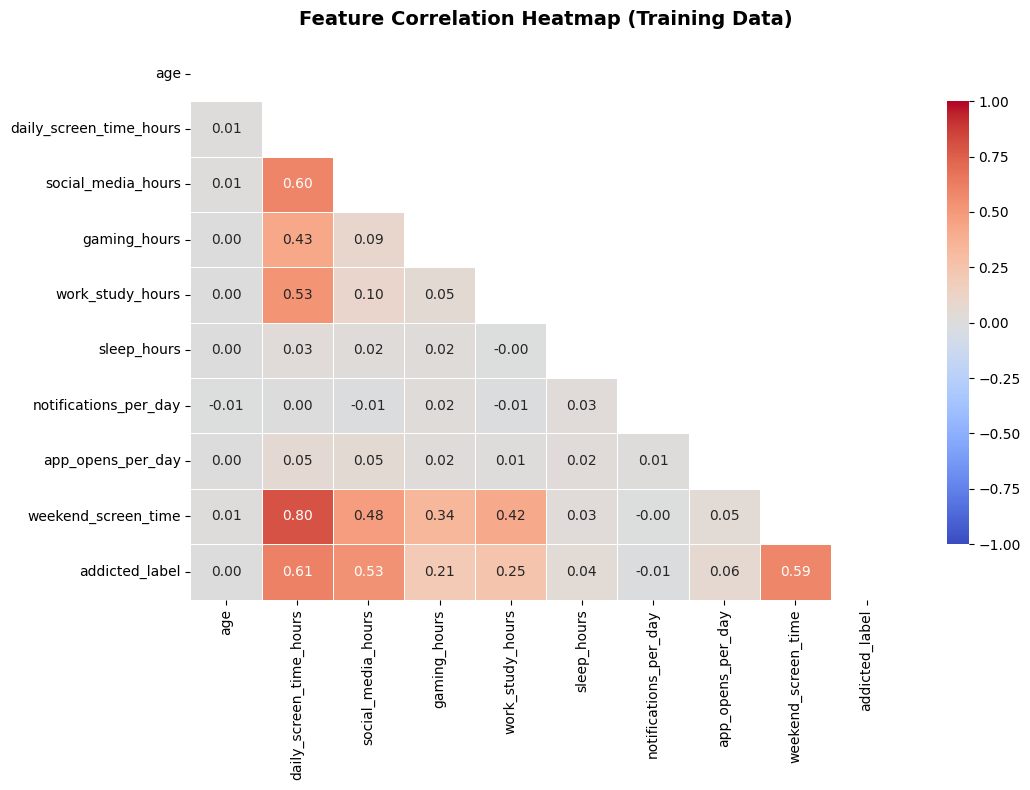

In [7]:
# Pearson Correlation Heatmap
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('id')

plt.figure(figsize=(11, 8))
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap (Training Data)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# 3. Behavioral Feature Engineering Pipeline

To capture non-linear behavioral patterns, time allocation ratios, and device engagement intensity, we engineer domain-specific features based on physical usage mechanics.

## Mathematical Definitions

1. **Total Leisure Hours ($H_{\text{leisure}}$)**:
$$H_{\text{leisure}} = H_{\text{social}} + H_{\text{gaming}}$$

2. **Leisure Proportion of Screen Time ($R_{\text{leisure}}$)**:
$$R_{\text{leisure}} = \frac{H_{\text{leisure}}}{H_{\text{daily}} + \epsilon}$$

3. **Weekend to Daily Screen Time Differential ($\Delta_{\text{weekend}}$)**:
$$\Delta_{\text{weekend}} = H_{\text{weekend}} - H_{\text{daily}}$$

4. **Session Granularity - Minutes per App Open ($M_{\text{session}}$)**:
$$M_{\text{session}} = \frac{H_{\text{daily}} \times 60}{N_{\text{app\_opens}} + \epsilon}$$

5. **Screen Time Percentage of Awake Hours ($P_{\text{awake}}$)**:
$$P_{\text{awake}} = \frac{H_{\text{daily}}}{24.0 - H_{\text{sleep}} + \epsilon}$$


In [8]:
def engineer_features(df):
    data = df.copy()
    eps = 1e-5
    
    # 1. Composite Usage Totals
    data['leisure_hours'] = data['social_media_hours'] + data['gaming_hours']
    data['productive_hours'] = data['work_study_hours']
    
    # 2. Ratios relative to Daily Screen Time
    data['social_media_ratio'] = data['social_media_hours'] / (data['daily_screen_time_hours'] + eps)
    data['gaming_ratio'] = data['gaming_hours'] / (data['daily_screen_time_hours'] + eps)
    data['work_study_ratio'] = data['work_study_hours'] / (data['daily_screen_time_hours'] + eps)
    data['leisure_ratio'] = data['leisure_hours'] / (data['daily_screen_time_hours'] + eps)
    
    # 3. Unaccounted / Other Screen Time
    data['unexplained_screen_hours'] = data['daily_screen_time_hours'] - (data['leisure_hours'].fillna(0) + data['work_study_hours'].fillna(0))
    
    # 4. Weekend Dynamics
    data['weekend_daily_diff'] = data['weekend_screen_time'] - data['daily_screen_time_hours']
    data['weekend_daily_ratio'] = data['weekend_screen_time'] / (data['daily_screen_time_hours'] + eps)
    
    # 5. Session Density Metrics
    data['mins_per_app_open'] = (data['daily_screen_time_hours'] * 60) / (data['app_opens_per_day'] + eps)
    data['notifications_per_app_open'] = data['notifications_per_day'] / (data['app_opens_per_day'] + eps)
    data['notifications_per_screen_hour'] = data['notifications_per_day'] / (data['daily_screen_time_hours'] + eps)
    
    # 6. Circadian Time Allocation
    data['awake_hours'] = 24.0 - data['sleep_hours']
    data['screen_pct_of_awake'] = data['daily_screen_time_hours'] / (data['awake_hours'] + eps)
    
    # 7. Row-level Missingness Count Metadata
    raw_feature_cols = [c for c in df.columns if c not in ['id', 'addicted_label']]
    data['missing_count'] = df[raw_feature_cols].isnull().sum(axis=1)
    
    return data

train_feat = engineer_features(train_df)
test_feat = engineer_features(test_df)

print(f"Engineered Training Shape: {train_feat.shape}")
print(f"Engineered Testing Shape:  {test_feat.shape}")


Engineered Training Shape: (691369, 29)
Engineered Testing Shape:  (296302, 28)


# 4. Cross-Validation Framework and Model Ensembling

## Mathematical Formulation of Evaluation Metric

The model optimization process evaluates predictions against binary addiction ground truth ($y_i \in \{0, 1\}$) using the **Area Under the Receiver Operating Characteristic Curve (ROC-AUC)**, equivalent to the probability that a randomly chosen positive sample receives a higher predicted score than a randomly chosen negative sample:

$$\text{ROC-AUC} = P(\hat{y}_i > \hat{y}_j \mid y_i = 1, y_j = 0)$$

## Stratified 5-Fold Scheme

To preserve class distribution proportions across splits, a **Stratified 5-Fold Cross-Validation** strategy is adopted. Out-of-fold probability vectors are recorded for each model architecture to facilitate meta-blending.


In [9]:
# Preprocessing Categorical Features
cat_features = ['gender', 'stress_level', 'academic_work_impact']
feature_cols = [c for c in train_feat.columns if c not in ['id', 'addicted_label']]

# Prepare data structures
X = train_feat[feature_cols].copy()
y = train_feat['addicted_label'].values
X_test = test_feat[feature_cols].copy()

# Ordinal Encoding for Categoricals
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_features] = encoder.fit_transform(X[cat_features].astype(str))
X_test[cat_features] = encoder.transform(X_test[cat_features].astype(str))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = {}
test_preds = {}


In [10]:
# Model 1: HistGradientBoostingClassifier (Native Scikit-Learn)
print("--- Training Model 1: HistGradientBoostingClassifier ---")
oof_hgb = np.zeros(len(train_df))
test_hgb = np.zeros(len(test_df))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_va = X.iloc[val_idx], y[val_idx]
    
    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=SEED + fold,
        early_stopping=True,
        n_iter_no_change=15
    )
    model.fit(X_tr, y_tr)
    
    val_pred = model.predict_proba(X_va)[:, 1]
    oof_hgb[val_idx] = val_pred
    test_hgb += model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    fold_auc = roc_auc_score(y_va, val_pred)
    print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")

score_hgb = roc_auc_score(y, oof_hgb)
print(f"HistGradientBoosting Overall OOF ROC-AUC: {score_hgb:.5f}\n")
oof_preds['HGB'] = oof_hgb
test_preds['HGB'] = test_hgb


--- Training Model 1: HistGradientBoostingClassifier ---
Fold 1 ROC-AUC: 0.95838
Fold 2 ROC-AUC: 0.95886
Fold 3 ROC-AUC: 0.95950
Fold 4 ROC-AUC: 0.95989
Fold 5 ROC-AUC: 0.95941
HistGradientBoosting Overall OOF ROC-AUC: 0.95920



In [11]:
# Model 2: LightGBM (Conditional execution)
if HAS_LGB:
    print("--- Training Model 2: LightGBM ---")
    oof_lgb = np.zeros(len(train_df))
    test_lgb = np.zeros(len(test_df))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_va, y_va = X.iloc[val_idx], y[val_idx]
        
        model = lgb.LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED + fold,
            n_jobs=-1,
            force_col_wise=True,
            verbosity=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        
        val_pred = model.predict_proba(X_va)[:, 1]
        oof_lgb[val_idx] = val_pred
        test_lgb += model.predict_proba(X_test)[:, 1] / skf.n_splits
        
        fold_auc = roc_auc_score(y_va, val_pred)
        print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")
        
    score_lgb = roc_auc_score(y, oof_lgb)
    print(f"LightGBM Overall OOF ROC-AUC: {score_lgb:.5f}\n")
    oof_preds['LGB'] = oof_lgb
    test_preds['LGB'] = test_lgb

--- Training Model 2: LightGBM ---
Fold 1 ROC-AUC: 0.96237
Fold 2 ROC-AUC: 0.96318
Fold 3 ROC-AUC: 0.96370
Fold 4 ROC-AUC: 0.96435
Fold 5 ROC-AUC: 0.96317
LightGBM Overall OOF ROC-AUC: 0.96335



In [12]:
# Model 3: XGBoost (Conditional execution)
if HAS_XGB:
    print("--- Training Model 3: XGBoost ---")
    oof_xgb = np.zeros(len(train_df))
    test_xgb = np.zeros(len(test_df))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_va, y_va = X.iloc[val_idx], y[val_idx]
        
        model = xgb.XGBClassifier(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED + fold,
            tree_method='hist',
            early_stopping_rounds=50,
            n_jobs=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        val_pred = model.predict_proba(X_va)[:, 1]
        oof_xgb[val_idx] = val_pred
        test_xgb += model.predict_proba(X_test)[:, 1] / skf.n_splits
        
        fold_auc = roc_auc_score(y_va, val_pred)
        print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")
        
    score_xgb = roc_auc_score(y, oof_xgb)
    print(f"XGBoost Overall OOF ROC-AUC: {score_xgb:.5f}\n")
    oof_preds['XGB'] = oof_xgb
    test_preds['XGB'] = test_xgb


--- Training Model 3: XGBoost ---
Fold 1 ROC-AUC: 0.96103
Fold 2 ROC-AUC: 0.96181
Fold 3 ROC-AUC: 0.96177
Fold 4 ROC-AUC: 0.96284
Fold 5 ROC-AUC: 0.96163
XGBoost Overall OOF ROC-AUC: 0.96181



In [13]:
# Model 4: CatBoost (Conditional execution)
if HAS_CB:
    print("--- Training Model 4: CatBoost ---")
    oof_cb = np.zeros(len(train_df))
    test_cb = np.zeros(len(test_df))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_va, y_va = X.iloc[val_idx], y[val_idx]
        
        model = cb.CatBoostClassifier(
            iterations=1000,
            learning_rate=0.04,
            depth=6,
            random_seed=SEED + fold,
            verbose=0,
            early_stopping_rounds=50
        )
        model.fit(
            X_tr, y_tr,
            eval_set=(X_va, y_va)
        )
        
        val_pred = model.predict_proba(X_va)[:, 1]
        oof_cb[val_idx] = val_pred
        test_cb += model.predict_proba(X_test)[:, 1] / skf.n_splits
        
        fold_auc = roc_auc_score(y_va, val_pred)
        print(f"Fold {fold + 1} ROC-AUC: {fold_auc:.5f}")
        
    score_cb = roc_auc_score(y, oof_cb)
    print(f"CatBoost Overall OOF ROC-AUC: {score_cb:.5f}\n")
    oof_preds['CB'] = oof_cb
    test_preds['CB'] = test_cb


--- Training Model 4: CatBoost ---
Fold 1 ROC-AUC: 0.95617
Fold 2 ROC-AUC: 0.95693
Fold 3 ROC-AUC: 0.95702
Fold 4 ROC-AUC: 0.95816
Fold 5 ROC-AUC: 0.95676
CatBoost Overall OOF ROC-AUC: 0.95700



# 5. Meta-Ensembling & Bounded Optimization

To combine individual model predictions into a robust final probability estimation, we find the optimal linear weights $w_k$ that maximize overall OOF ROC-AUC:

$$\max_{\mathbf{w}} \text{ROC-AUC}\left(y, \sum_{k=1}^{K} w_k \hat{y}^{(k)}\right) \quad \text{subject to} \quad \sum_{k=1}^{K} w_k = 1, \quad w_k \ge 0$$


In [14]:
# Mathematical Optimization for Optimal Blending Weights
model_names = list(oof_preds.keys())
OOF_matrix = np.column_stack([oof_preds[m] for m in model_names])
TEST_matrix = np.column_stack([test_preds[m] for m in model_names])

def loss_func(weights):
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    blend_oof = np.dot(OOF_matrix, weights)
    return -roc_auc_score(y, blend_oof)

init_weights = [1.0 / len(model_names)] * len(model_names)
bounds = [(0, 1)] * len(model_names)
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})

res = minimize(loss_func, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights = res.x / np.sum(res.x)

print("--- Optimal Ensemble Weights ---")
for name, w in zip(model_names, opt_weights):
    print(f"{name}: {w:.4f}")

final_oof_blend = np.dot(OOF_matrix, opt_weights)
final_ensemble_auc = roc_auc_score(y, final_oof_blend)
print(f"\nFinal Meta-Ensemble Out-of-Fold ROC-AUC: {final_ensemble_auc:.5f}")


--- Optimal Ensemble Weights ---
HGB: 0.0000
LGB: 0.4427
XGB: 0.4324
CB: 0.1249

Final Meta-Ensemble Out-of-Fold ROC-AUC: 0.96257


# 6. Final Submission Generation & Verification

We apply the computed optimal meta-weights to construct the final test set probabilities and perform verification checks prior to file export.


In [15]:
final_test_preds = np.dot(TEST_matrix, opt_weights)

submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': final_test_preds
})

assert len(submission) == len(test_df), "Row count mismatch between submission and test set!"
assert submission['addicted_label'].isnull().sum() == 0, "Submission contains null values!"
assert (submission['addicted_label'] >= 0).all() and (submission['addicted_label'] <= 1).all(), "Predictions out of bounds!"

submission.to_csv('submission.csv', index=False)
print("Submission successfully created and saved as 'submission.csv'.")
print(f"Submission Shape: {submission.shape}")
print("\nFirst 10 Rows:")
display(submission.head(10))


Submission successfully created and saved as 'submission.csv'.
Submission Shape: (296302, 2)

First 10 Rows:


,id,addicted_label
0,691369,0.998926
1,691370,0.937003
2,691371,0.963846
3,691372,0.983284
4,691373,0.997117
5,691374,0.886509
6,691375,0.889092
7,691376,0.546525
8,691377,0.981821
9,691378,0.374070
